<a href="https://colab.research.google.com/github/Tanu-AI-Space/Learning-DeepLearning/blob/main/Vanishing_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [76]:
X,y = make_moons(n_samples=250,noise=0.05,random_state=42)

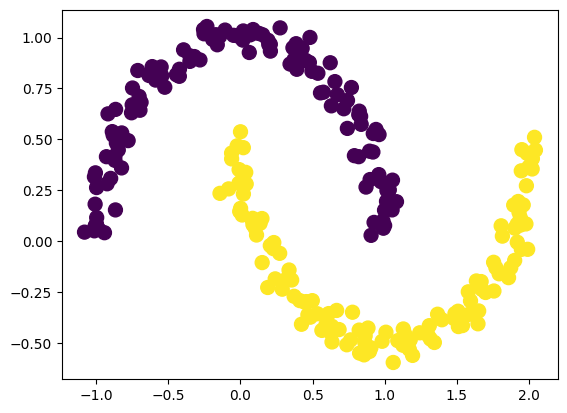

In [77]:
plt.scatter(X[:,0],X[:,1],c=y,s=100)

In [78]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [79]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [80]:
model.get_weights()

[array([[-0.18570846, -0.09165639,  0.09725535, -0.16673815,  0.24887174,
         -0.4035173 ,  0.5073424 , -0.31825203,  0.5959498 , -0.19000256],
        [ 0.6248186 , -0.0166527 , -0.50194687, -0.00278521, -0.70063454,
          0.4581595 , -0.30265972,  0.20229799, -0.16594714,  0.67165154]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.39861768, -0.02372694, -0.26039097,  0.05651909, -0.40667087,
         -0.25861368,  0.42006987, -0.03634006, -0.24944708,  0.40126508],
        [ 0.24147719, -0.40372494,  0.1465041 ,  0.13851482, -0.2686933 ,
          0.3859464 ,  0.11418772, -0.5369926 ,  0.32605463,  0.32028347],
        [-0.00492847,  0.38716763,  0.28921968,  0.37766093,  0.34718275,
         -0.40894777,  0.18647349,  0.0279476 , -0.32543683,  0.41302395],
        [-0.42344454,  0.34498823,  0.06884456,  0.4865055 , -0.3721308 ,
         -0.43159866, -0.10835516, -0.3420124 ,  0.3369949 , -0.40259823],
        [ 0.13602

In [81]:
old_weights = model.get_weights()[0]
old_weights

array([[-0.18570846, -0.09165639,  0.09725535, -0.16673815,  0.24887174,
        -0.4035173 ,  0.5073424 , -0.31825203,  0.5959498 , -0.19000256],
       [ 0.6248186 , -0.0166527 , -0.50194687, -0.00278521, -0.70063454,
         0.4581595 , -0.30265972,  0.20229799, -0.16594714,  0.67165154]],
      dtype=float32)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [83]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7000 - loss: 0.6923
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7900 - loss: 0.6899 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7950 - loss: 0.6866 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7950 - loss: 0.6821
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7850 - loss: 0.6768
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7950 - loss: 0.6692
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7900 - loss: 0.6601 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7950 - loss: 0.6452
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7950 - loss: 0.6254
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8050 - loss: 0.6025 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8150 - loss: 0.5676
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8200 - lo

In [84]:
new_weights = model.get_weights()[0]

In [85]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [86]:
gradient = (old_weights - new_weights)/0.001
percent_change = abs(100*(old_weights-new_weights)/old_weights)

In [87]:
gradient

array([[  13.779819 ,  -52.333218 , -141.55202  ,  -96.52484  ,
         153.944    ,  113.411064 ,   26.395557 ,  -10.0242195,
        -134.96881  ,  -43.335495 ],
       [-111.45847  ,   27.060482 ,  131.7532   ,   56.75678  ,
         -40.78716  ,  -46.919224 ,   98.64992  ,  -86.773865 ,
         -33.230156 ,  -71.52611  ]], dtype=float32)

In [88]:
percent_change

array([[   7.420135 ,   57.09719  ,  145.54678  ,   57.89007  ,
          61.85676  ,   28.105625 ,    5.202711 ,    3.149774 ,
          22.64768  ,   22.807848 ],
       [  17.838533 ,  162.49904  ,   26.248436 , 2037.7947   ,
           5.8214602,   10.240806 ,   32.594334 ,   42.894085 ,
          20.024544 ,   10.649288 ]], dtype=float32)

In [89]:
model = Sequential()